In [2]:
# !pip install shap matplotlib openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]


/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.aiplatform_v1beta1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1beta1 past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.aiplatform_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1 past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_supp

  0%|          | 0/1 [00:00<?, ?it/s]

解析完了。可視化を表示します...


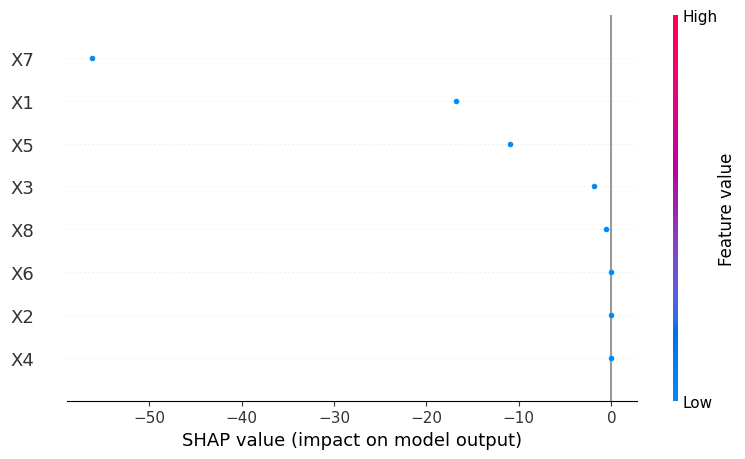

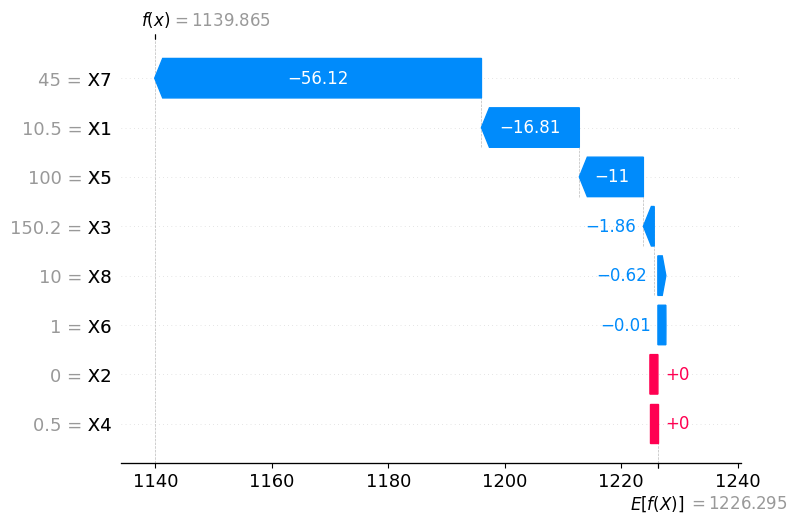

In [3]:
# import pandas as pd
# import numpy as np
# import shap
# from google.cloud import aiplatform

# # 1. Vertex AI エンドポイントの設定
# project_id = "qwiklabs-asl-00-8534302ca246"
# location = "us-central1"
# endpoint_id = "1142366742736011264" # 画像から取得

# aiplatform.init(project=project_id, location=location)
# endpoint = aiplatform.Endpoint(endpoint_id)

# # 2. データの読み込み
# df_external = pd.read_excel("base_input.xlsx")

# # 3. SHAP解析用の予測関数を定義
# # Vertex AIのエンドポイントを呼び出す形式にラップします
# def predict_func(X):
#     # Xはnumpy配列で渡されるためリストに変換
#     instances = X.tolist()
#     response = endpoint.predict(instances=instances)
#     return np.array(response.predictions)

# # 4. SHAP解析の実行
# def run_vertex_shap_analysis(X_data):
#     # 学習データの背景分布としてX_dataを使用（KernelExplainerは汎用性が高い）
#     # MLP等の非線形モデルにも対応可能です 
#     explainer = shap.KernelExplainer(predict_func, shap.sample(X_data, 10))  # 10個のデータで予測かけていた
    
#     # 最初の1行（base_row）のSHAP値を計算 
#     test_row = X_data.iloc[:1]
#     shap_values = explainer.shap_values(test_row)
    
#     print("解析完了。可視化を表示します...")
    
#     # 特徴量ごとの寄与度をプロット [cite: 3]
#     # カテゴリ変数が数値化されていれば、その寄与が可視化されます 
#     shap.summary_plot(shap_values, test_row)
    
#     # 決定プロセスの可視化（Waterfall Plot） [cite: 3]
#     # 注: KernelExplainerの結果をwaterfallに渡すにはExplanationオブジェクト化が必要
#     explanation = shap.Explanation(
#         values=shap_values[0], 
#         base_values=explainer.expected_value, 
#         data=test_row.iloc[0],
#         feature_names=test_row.columns.tolist()
#     )
#     shap.plots.waterfall(explanation)

# # 実行
# run_vertex_shap_analysis(df_external)

SHAP値を計算中...（全データを背景にしているため時間がかかる場合があります）


  0%|          | 0/1 [00:00<?, ?it/s]

解析完了。期待値 E[f(X)]: 23.553106890757995


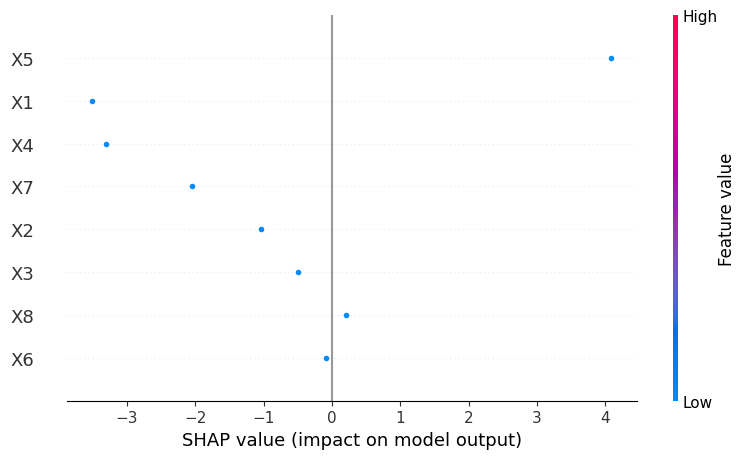

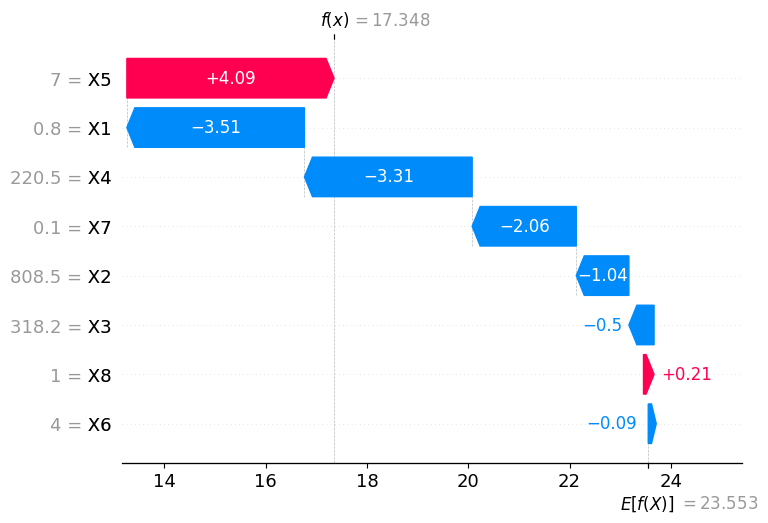

In [7]:
import pandas as pd
import numpy as np
import shap
from google.cloud import aiplatform

# 1. Vertex AI エンドポイントの設定
project_id = "qwiklabs-asl-00-8534302ca246"
location = "us-central1"
# endpoint_id = "1142366742736011264"
endpoint_id = "199495939499491328"

aiplatform.init(project=project_id, location=location)
endpoint = aiplatform.Endpoint(endpoint_id)

# 2. データの読み込み
# df_external = pd.read_excel("base_input.xlsx")
df_external = pd.read_csv("test_data.csv")

# 3. 予測関数の定義
def predict_func(X):
    instances = X.tolist()
    response = endpoint.predict(instances=instances)
    return np.array(response.predictions)

# 4. SHAP解析の実行
def run_vertex_shap_analysis(X_data):
    # --- 修正ポイント：background_data を全データにする ---
    # もしデータ件数が多すぎてエラーが出る場合は、shap.kmeans(X_data, 20) 
    # などを検討してください。これは全データの統計的特徴を維持したまま圧縮する手法です。
    background_data = X_data 
    
    # KernelExplainerに全データを渡す
    explainer = shap.KernelExplainer(predict_func, background_data)
    
    # 最初の1行のSHAP値を計算
    test_row = X_data.iloc[:1]
    
    # 全データを背景にすると計算に時間がかかるため、進捗を表示
    print("SHAP値を計算中...（全データを背景にしているため時間がかかる場合があります）")
    shap_values = explainer.shap_values(test_row)
    
    print(f"解析完了。期待値 E[f(X)]: {explainer.expected_value}")
    
    # 可視化：Summary Plot
    shap.summary_plot(shap_values, test_row)
    
    # 可視化：Waterfall Plot
    explanation = shap.Explanation(
        values=shap_values[0], 
        base_values=explainer.expected_value, 
        data=test_row.iloc[0],
        feature_names=test_row.columns.tolist()
    )
    shap.plots.waterfall(explanation)

# 実行
run_vertex_shap_analysis(df_external)

背景データを50件に要約中...

解析実行中: Pattern 1 (data1)


  0%|          | 0/1 [00:00<?, ?it/s]

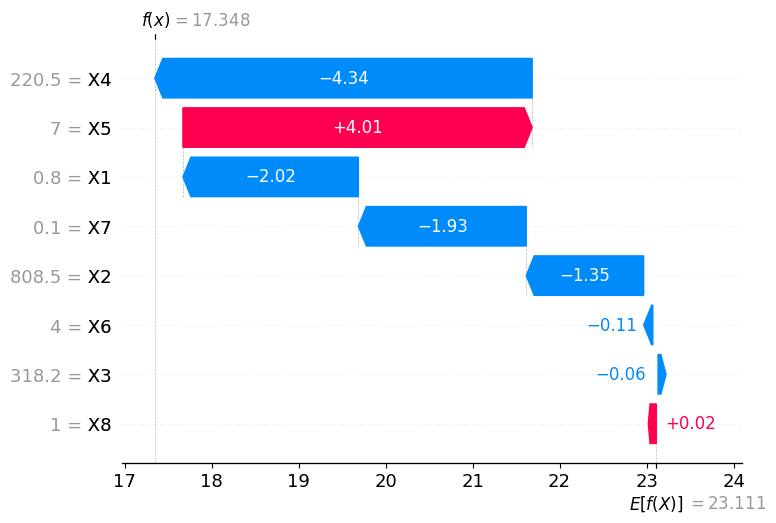


解析実行中: Pattern 2 (data2)


  0%|          | 0/1 [00:00<?, ?it/s]

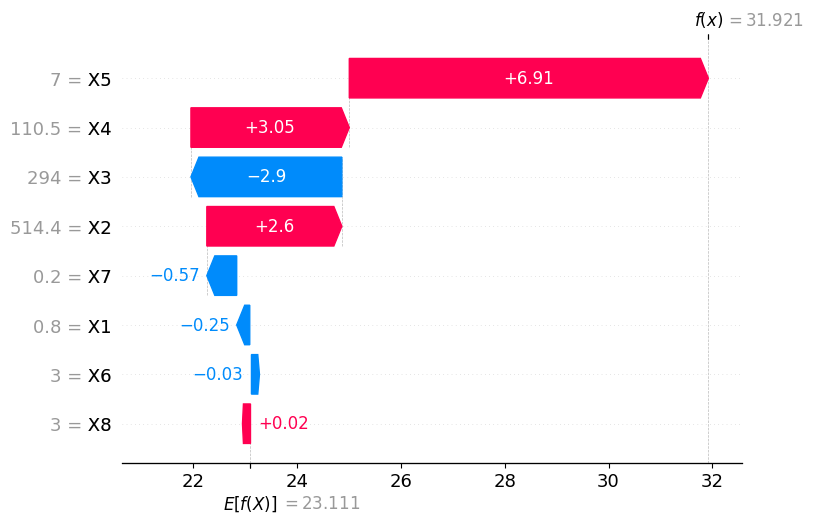

In [12]:
import pandas as pd
import numpy as np
import shap
from google.cloud import aiplatform

# 1. Vertex AI エンドポイントの設定
project_id = "qwiklabs-asl-00-8534302ca246"
location = "us-central1"
endpoint_id = "199495939499491328"

aiplatform.init(project=project_id, location=location)
endpoint = aiplatform.Endpoint(endpoint_id)

# 2. データの読み込みと列の絞り込み
df_raw = pd.read_csv("test_data.csv")
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
df_external = df_raw[feature_cols]

# 3. 解析用データの作成
data1 = {'X1': [0.8], 'X2': [808.5], 'X3': [318.2], 'X4': [220.5], 'X5': [7], 'X6': [4], 'X7': [0.1], 'X8': [1]}
data2 = {'X1': [0.8], 'X2': [514.4], 'X3': [294.0], 'X4': [110.5], 'X5': [7], 'X6': [3], 'X7': [0.2], 'X8': [3]}

test_rows = [pd.DataFrame(data1), pd.DataFrame(data2)]
labels = ["Pattern 1 (data1)", "Pattern 2 (data2)"]

# 4. 予測関数の定義（バッチ処理対応版）
def predict_func(X):
    # SHAPが生成した大量のデータを100行ずつに分割して送信する
    batch_size = 100
    all_predictions = []
    
    instances = X.tolist()
    
    for i in range(0, len(instances), batch_size):
        batch = instances[i : i + batch_size]
        response = endpoint.predict(instances=batch)
        all_predictions.extend(response.predictions)
        
    return np.array(all_predictions)

# 5. SHAP解析の実行関数
def run_vertex_shap_analysis_custom(test_rows, labels, background_data):
    # 背景データを50件に少し減らして、さらに計算を安定させます
    n_background = 50
    if len(background_data) > n_background:
        print(f"背景データを{n_background}件に要約中...")
        summary_background = shap.kmeans(background_data, n_background)
    else:
        summary_background = background_data
        
    # nsamples を指定して、1回あたりの計算負荷を調整
    explainer = shap.KernelExplainer(predict_func, summary_background)
    
    for row, label in zip(test_rows, labels):
        print(f"\n{'='*30}\n解析実行中: {label}\n{'='*30}")
        
        # nsamplesを小さめに設定（例: 100〜300）すると、よりエラーが出にくくなります
        shap_values = explainer.shap_values(row, nsamples=200)
        current_shap_values = shap_values[0] if isinstance(shap_values, list) else shap_values
        
        explanation = shap.Explanation(
            values=current_shap_values[0], 
            base_values=explainer.expected_value, 
            data=row.iloc[0].values,
            feature_names=row.columns.tolist()
        )
        shap.plots.waterfall(explanation)

# 6. 実行
run_vertex_shap_analysis_custom(test_rows, labels, df_external)

■全データ（線形）

全データ（768件）をベースに期待値を計算中...


Using 768 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.



★ 全データに基づく期待値 E[f(X)]: 21.440753972466442

解析実行中: Pattern 1 (data1)


  0%|          | 0/1 [00:00<?, ?it/s]

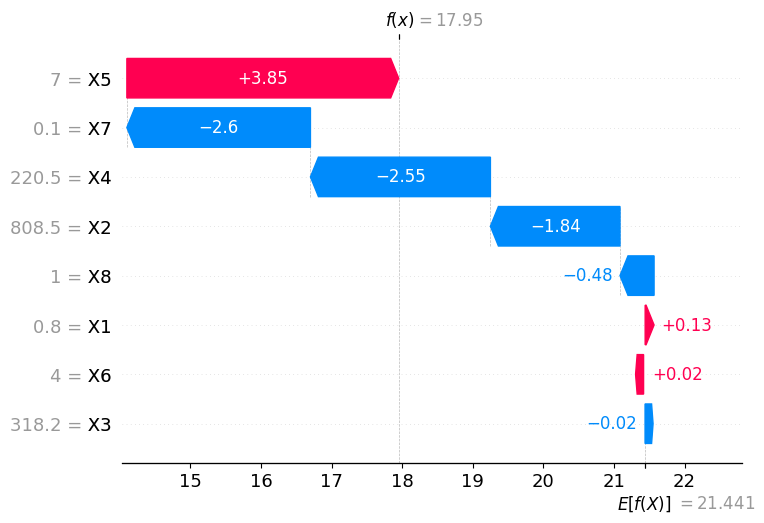


解析実行中: Pattern 2 (data2)


  0%|          | 0/1 [00:00<?, ?it/s]

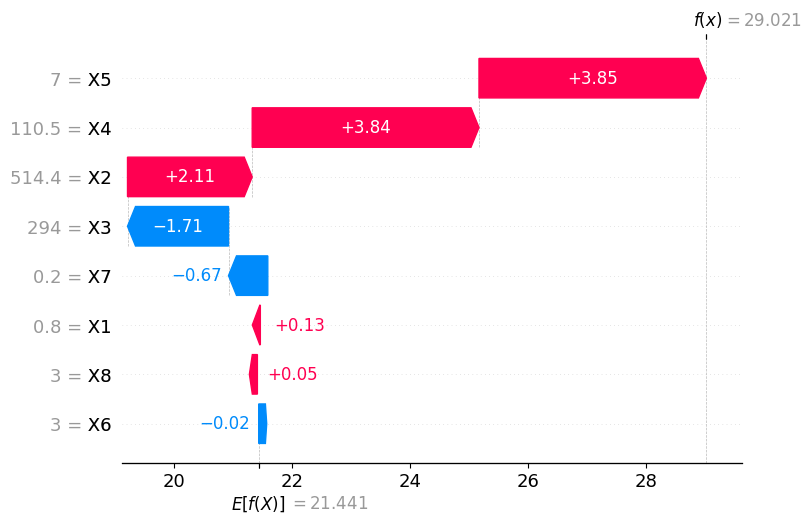

In [16]:
import pandas as pd
import numpy as np
import shap
from google.cloud import aiplatform

# 1. Vertex AI エンドポイントの設定
project_id = "qwiklabs-asl-00-8534302ca246"
location = "us-central1"
endpoint_id = "1142366742736011264"
# endpoint_id = "199495939499491328" NN

aiplatform.init(project=project_id, location=location)
endpoint = aiplatform.Endpoint(endpoint_id)

# 2. データの読み込みと列の絞り込み
# df_raw = pd.read_csv("test_data.csv")
# feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
# df_external = df_raw[feature_cols]

# GCS上のファイルパス（gs://バケット名/ファイル名）
file_path = "gs://qwiklabs-asl-00-8534302ca246-data/ENB2012_data.xlsx"
# pandasで読み込み
df_raw = pd.read_excel(file_path)
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
df_external = df_raw[feature_cols]

# 3. 解析用データの作成
data1 = {'X1': [0.8], 'X2': [808.5], 'X3': [318.2], 'X4': [220.5], 'X5': [7], 'X6': [4], 'X7': [0.1], 'X8': [1]}
data2 = {'X1': [0.8], 'X2': [514.4], 'X3': [294.0], 'X4': [110.5], 'X5': [7], 'X6': [3], 'X7': [0.2], 'X8': [3]}

test_rows = [pd.DataFrame(data1), pd.DataFrame(data2)]
labels = ["Pattern 1 (data1)", "Pattern 2 (data2)"]

# 4. 予測関数の定義（バッチ処理対応版）
def predict_func(X):
    # SHAPが生成した大量のデータを100行ずつに分割して送信する
    batch_size = 100
    all_predictions = []
    
    instances = X.tolist()
    
    for i in range(0, len(instances), batch_size):
        batch = instances[i : i + batch_size]
        response = endpoint.predict(instances=batch)
        all_predictions.extend(response.predictions)
        
    return np.array(all_predictions)

# 5. SHAP解析の実行関数
def run_vertex_shap_analysis_full_background(test_rows, labels, background_data):
    """
    background_data: test_data.csv から抽出した全データ
    """
    # 修正ポイント：kmeansを使わず、全データをそのまま渡す
    # これにより E[f(X)] は「全データの予測値の平均」になります
    print(f"全データ（{len(background_data)}件）をベースに期待値を計算中...")
    explainer = shap.KernelExplainer(predict_func, background_data)
    
    # 全データを背景にした場合の期待値を表示
    print(f"\n★ 全データに基づく期待値 E[f(X)]: {explainer.expected_value}")

    for row, label in zip(test_rows, labels):
        print(f"\n{'='*30}\n解析実行中: {label}\n{'='*30}")
        
        # SHAP値の計算（ここが最も時間がかかるため、バッチ処理とnsamplesが重要）
        # 全データが背景の場合、nsamplesを増やすと精度が上がりますが、まずは300程度を推奨
        shap_values = explainer.shap_values(row, nsamples=300)
        current_shap_values = shap_values[0] if isinstance(shap_values, list) else shap_values
        
        explanation = shap.Explanation(
            values=current_shap_values[0], 
            base_values=explainer.expected_value, 
            data=row.iloc[0].values,
            feature_names=row.columns.tolist()
        )
        shap.plots.waterfall(explanation)

# 6. 実行
# df_external は test_data.csv の 8列をすべて含んだ DataFrame
run_vertex_shap_analysis_full_background(test_rows, labels, df_external)

■全データ（NN）

全データ（768件）をベースに期待値を計算中...


Using 768 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.



★ 全データに基づく期待値 E[f(X)]: 22.305293225865142

解析実行中: Pattern 1 (data1)


  0%|          | 0/1 [00:00<?, ?it/s]

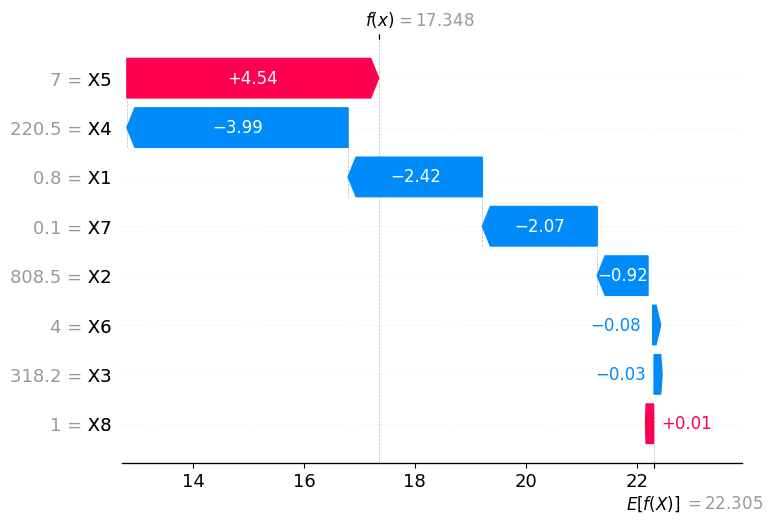


解析実行中: Pattern 2 (data2)


  0%|          | 0/1 [00:00<?, ?it/s]

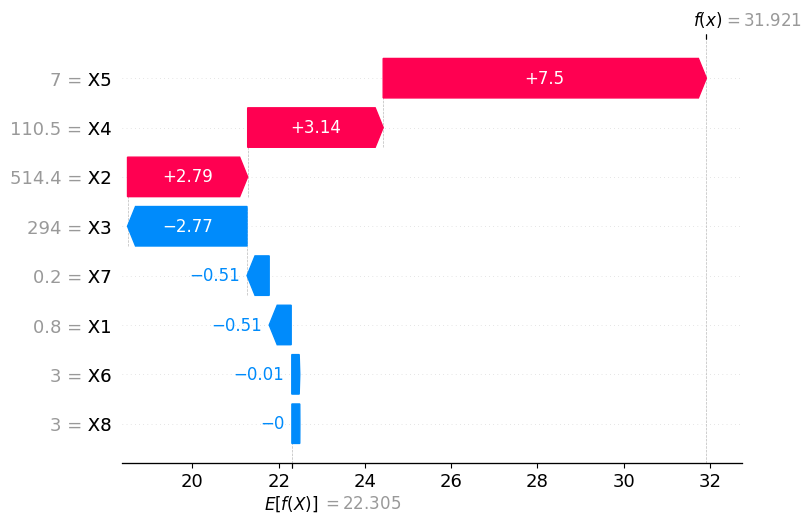

In [14]:
import pandas as pd
import numpy as np
import shap
from google.cloud import aiplatform

# 1. Vertex AI エンドポイントの設定
project_id = "qwiklabs-asl-00-8534302ca246"
location = "us-central1"
endpoint_id = "199495939499491328"

aiplatform.init(project=project_id, location=location)
endpoint = aiplatform.Endpoint(endpoint_id)

# 2. データの読み込みと列の絞り込み
# df_raw = pd.read_csv("test_data.csv")
# feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
# df_external = df_raw[feature_cols]

# GCS上のファイルパス（gs://バケット名/ファイル名）
file_path = "gs://qwiklabs-asl-00-8534302ca246-data/ENB2012_data.xlsx"
# pandasで読み込み
df_raw = pd.read_excel(file_path)
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
df_external = df_raw[feature_cols]

# 3. 解析用データの作成
data1 = {'X1': [0.8], 'X2': [808.5], 'X3': [318.2], 'X4': [220.5], 'X5': [7], 'X6': [4], 'X7': [0.1], 'X8': [1]}
data2 = {'X1': [0.8], 'X2': [514.4], 'X3': [294.0], 'X4': [110.5], 'X5': [7], 'X6': [3], 'X7': [0.2], 'X8': [3]}

test_rows = [pd.DataFrame(data1), pd.DataFrame(data2)]
labels = ["Pattern 1 (data1)", "Pattern 2 (data2)"]

# 4. 予測関数の定義（バッチ処理対応版）
def predict_func(X):
    # SHAPが生成した大量のデータを100行ずつに分割して送信する
    batch_size = 100
    all_predictions = []
    
    instances = X.tolist()
    
    for i in range(0, len(instances), batch_size):
        batch = instances[i : i + batch_size]
        response = endpoint.predict(instances=batch)
        all_predictions.extend(response.predictions)
        
    return np.array(all_predictions)

# 5. SHAP解析の実行関数
def run_vertex_shap_analysis_full_background(test_rows, labels, background_data):
    """
    background_data: test_data.csv から抽出した全データ
    """
    # 修正ポイント：kmeansを使わず、全データをそのまま渡す
    # これにより E[f(X)] は「全データの予測値の平均」になります
    print(f"全データ（{len(background_data)}件）をベースに期待値を計算中...")
    explainer = shap.KernelExplainer(predict_func, background_data)
    
    # 全データを背景にした場合の期待値を表示
    print(f"\n★ 全データに基づく期待値 E[f(X)]: {explainer.expected_value}")

    for row, label in zip(test_rows, labels):
        print(f"\n{'='*30}\n解析実行中: {label}\n{'='*30}")
        
        # SHAP値の計算（ここが最も時間がかかるため、バッチ処理とnsamplesが重要）
        # 全データが背景の場合、nsamplesを増やすと精度が上がりますが、まずは300程度を推奨
        shap_values = explainer.shap_values(row, nsamples=300)
        current_shap_values = shap_values[0] if isinstance(shap_values, list) else shap_values
        
        explanation = shap.Explanation(
            values=current_shap_values[0], 
            base_values=explainer.expected_value, 
            data=row.iloc[0].values,
            feature_names=row.columns.tolist()
        )
        shap.plots.waterfall(explanation)

# 6. 実行
# df_external は test_data.csv の 8列をすべて含んだ DataFrame
run_vertex_shap_analysis_full_background(test_rows, labels, df_external)

■最適値の導出

In [7]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from google.cloud import aiplatform

# 1. Vertex AI エンドポイントの設定
endpoint = aiplatform.Endpoint(endpoint_id)

# 2. 最適化の設定（ここを調整してください）
TARGET_Y1 = 50.0  # あなたが達成したい理想の予測値

# 調整したい3つの因子名
FEATURES_TO_TUNE = ["X7", "X1", "X5"] 

# 各因子の探索範囲（最小値, 最大値）
USER_CONSTRAINTS = {
    "X7": (0, 100),    # 例: 現状45だが、0〜100の範囲で探す
    "X1": (0.0, 50.0),
    "X5": (0, 500)
}

# 3. 目的関数の定義（予測値と目標値の差の二乗を最小化） [cite: 7]
def objective(params, base_row):
    # ベースデータをコピーして調整対象だけ書き換える [cite: 6]
    current_input = base_row.copy().to_frame().T
    for i, feat in enumerate(FEATURES_TO_TUNE):
        current_input[feat] = params[i]
    
    # Vertex AIエンドポイントで予測
    instances = current_input.astype(float).values.tolist()
    response = endpoint.predict(instances=instances)
    y_pred = response.predictions[0]
    
    return (y_pred - TARGET_Y1) ** 2

# 4. 最適化の実行関数
def run_optimization(df_data):
    # 解析対象の行（例：最初の1行）をベースにする [cite: 2]
    base_row = df_data.iloc[0]
    
    # 初期値と境界条件の設定 [cite: 5]
    x0 = [base_row[f] for f in FEATURES_TO_TUNE]
    bounds = [USER_CONSTRAINTS[f] for f in FEATURES_TO_TUNE]
    
    print(f"最適化を開始します... 目標値 Y1: {TARGET_Y1}")
    
    # 最適化計算の実行 [cite: 7]
    res = minimize(objective, x0, args=(base_row,), bounds=bounds, method='L-BFGS-B')
    
    # 結果の反映 [cite: 8]
    tuned_params = res.x
    best_input = base_row.copy().to_frame().T
    for i, feat in enumerate(FEATURES_TO_TUNE):
        best_input[feat] = tuned_params[i]
    
    # 最終予測値の確認
    final_instances = best_input.astype(float).values.tolist()
    final_pred = endpoint.predict(instances=final_instances).predictions[0]
    
    print("-" * 30)
    print(f"【最適化結果】")
    print(f"目標値: {TARGET_Y1} / 達成予測値: {final_pred:.4f}")
    print(f"推奨される設定:")
    for i, feat in enumerate(FEATURES_TO_TUNE):
        print(f"  - {feat}: {base_row[feat]} -> {tuned_params[i]:.4f}")
    
    if abs(final_pred - TARGET_Y1) > 0.1:
        print("\n※モデルの特性上、制約内では目標に届きませんでした。制約を緩めるかSHAP依存関係プロットを確認してください。 ")
    
    return best_input

# 実行
result_df = run_optimization(df_external)

最適化を開始します... 目標値 Y1: 50.0
------------------------------
【最適化結果】
目標値: 50.0 / 達成予測値: 50.0000
推奨される設定:
  - X7: 0.1 -> 0.8195
  - X1: 0.8 -> 0.7967
  - X5: 7.0 -> 9.5389


■他を固定して、任意の変数の最適値を求めるコード

ケース１，２など、固定する値をエクセル等で、事前に準備しておく必要がある

In [8]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from google.cloud import aiplatform

# 1. Vertex AI エンドポイントの設定
endpoint = aiplatform.Endpoint(endpoint_id)

# 2. 条件の設定
TARGET_Y1 = 16.47        # 目標値
VARIABLE_FEATURE = "X7" # 逆算したい変数
# それ以外の変数の固定値を指定
FIXED_VALUES = {
    "X1": 0.62,
    "X2": 808.5,
    "X3": 367.5,
    "X4": 220.5,
    "X5": 3.5,
    "X6": 2,
    "X8": 3
}
# X7の探索範囲
X7_BOUNDS = (0.0, 10.0) 

# 特徴量の並び順（モデルの入力形式に合わせる）
ordered_features = ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"]

# 3. 目的関数の定義
def objective_single(x_val):
    input_dict = FIXED_VALUES.copy()
    input_dict[VARIABLE_FEATURE] = x_val[0]
    
    input_row = [input_dict[f] for f in ordered_features]
    
    response = endpoint.predict(instances=[input_row])
    y_pred = response.predictions[0]
    
    return (y_pred - TARGET_Y1) ** 2

# 4. 最適化の実行関数
def run_single_optimization():
    # 初期値（範囲の中間値など）
    x0 = [(X7_BOUNDS[0] + X7_BOUNDS[1]) / 2]
    
    print(f"【単一変数最適化】実行中...")
    print(f"ターゲット目標値 Y1 = {TARGET_Y1}")
    
    res = minimize(objective_single, x0, bounds=[X7_BOUNDS], method='L-BFGS-B')
    
    print("\n" + "="*40)
    print("  最適化シミュレーション結果報告書")
    print("="*40)
    
    # 前提条件（固定値）の表示
    print(" [前提条件: 固定された因子]")
    for feat in ordered_features:
        if feat != VARIABLE_FEATURE:
            print(f"  - {feat:3}: {FIXED_VALUES[feat]:>10}")
            
    print("-" * 40)
    
    if res.success:
        optimized_val = res.x[0]
        # 最終確認の予測
        final_input = [FIXED_VALUES.get(f, optimized_val) for f in ordered_features]
        final_pred = endpoint.predict(instances=[final_input]).predictions[0]
        
        # 逆算結果の表示
        print(f" [逆算結果: 調整した因子]")
        print(f"  * {VARIABLE_FEATURE:3}: {optimized_val:>10.4f} (推奨設定値)")
        
        print("-" * 40)
        print(f" [予測評価]")
        print(f"  最終予測 Y1 : {final_pred:.4f}")
        print(f"  目標との差  : {abs(final_pred - TARGET_Y1):.4f}")
    else:
        print(" エラー: 最適解が見つかりませんでした。")
    print("="*40)

# 実行
run_single_optimization()

【単一変数最適化】実行中...
ターゲット目標値 Y1 = 16.47

  最適化シミュレーション結果報告書
 [前提条件: 固定された因子]
  - X1 :       0.62
  - X2 :      808.5
  - X3 :      367.5
  - X4 :      220.5
  - X5 :        3.5
  - X6 :          2
  - X8 :          3
----------------------------------------
 [逆算結果: 調整した因子]
  * X7 :     0.4302 (推奨設定値)
----------------------------------------
 [予測評価]
  最終予測 Y1 : 16.4700
  目標との差  : 0.0000
